In [1]:
import numpy as np
from tensorflow.keras import layers, models


In [2]:
data_run1 = np.load("C:/Users/Sanjana/Downloads/Run355456_Dataset_jqkne.npy")
data_run2 = np.load("C:/Users/Sanjana/Downloads/Run357479_Dataset_iodic.npy")

print("Run1 shape:", data_run1.shape)
print("Run2 shape:", data_run2.shape)
print("Run1 dtype:", data_run1.dtype)
print("Run2 dtype:", data_run2.dtype)


Run1 shape: (10000, 64, 72)
Run2 shape: (10000, 64, 72)
Run1 dtype: float64
Run2 dtype: float64


In [4]:
X_train = data_run1 / np.max(data_run1)
X_test = data_run2 / np.max(data_run2) 


In [5]:
y_train = np.zeros(len(X_train))  # Run A = 0
y_test = np.ones(len(X_test))     # Run B = 1


In [6]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Final train shape:", X_train.shape)
print("Final test shape:", X_test.shape)


Final train shape: (10000, 64, 72, 1)
Final test shape: (10000, 64, 72, 1)


In [7]:
# Per-image normalization
X_train = X_train / (X_train.max(axis=(1,2), keepdims=True) + 1e-8)
X_test  = X_test  / (X_test.max(axis=(1,2), keepdims=True) + 1e-8)


In [8]:

from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', input_shape=(64,72,1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])


C:\Users\Sanjana\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [10]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 222ms/step - accuracy: 0.9573 - loss: 0.1263 - val_accuracy: 0.0000e+00 - val_loss: 182.8824
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 214ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 0.0000e+00 - val_loss: 285.6204
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 216ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.0000e+00 - val_loss: 333.5942
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 75s 239ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.0000e+00 - val_loss: 317.1887
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 223ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.0000e+00 - val_loss: 366.3062


In [12]:
model.predict(X_train[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step


array([[2.7109105e-14]], dtype=float32)

In [15]:
feature_model = Model(
    inputs=model.layers[0].input,
    outputs=model.layers[-2].output
)

In [18]:
features_A = feature_model.predict(data_run1)
features_B = feature_model.predict(data_run2)

print("Feature shape A:", features_A.shape)
print("Feature shape B:", features_B.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step
Feature shape A: (10000, 128)
Feature shape B: (10000, 128)


In [19]:
import numpy as np

X_features = np.vstack([features_A, features_B])
labels = np.array([0]*len(features_A) + [1]*len(features_B))

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features)

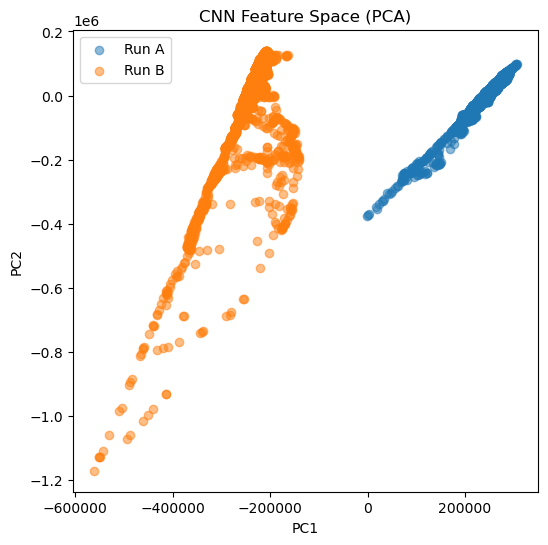

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(X_pca[labels==0,0], X_pca[labels==0,1], 
            alpha=0.5, label="Run A")
plt.scatter(X_pca[labels==1,0], X_pca[labels==1,1], 
            alpha=0.5, label="Run B")

plt.legend()
plt.title("CNN Feature Space (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()